# Strategy 1: Algorithmic Liquidity Sweeps

## 1. Strategy overview
Liquidity Sweeps focus on identifying price manipulation around key historical levels (Equal Highs / Equal Lows). 
When price breaches a key swing level to trigger retail stop-losses and immediately closes back inside the previous range, an institutional sweep signal is identified.

## 2. Theoretical rules
* **Liquidity Identification:** Local swing highs/lows over a rolling $N$-period window.
* **Sweep Detection:** Candle wick breaches the swing high/low, but the closing price stays inside the range.
* **Entry:** Market order on the next open candle post-sweep.
* **Exit:** Target set at the opposing swing level or fixed Risk-to-Reward ratio ($1:3$).


Note: all the prints are commented for not saturanting the output (# COMMENTED_PRINT:). The prints are useful to compare the algorythm outputs with real charts and verify it is working as expected. After veryfication, one can just make the plots. 


 Starting SWEEP backtest for US500.cash
         PERFORMANCE METRICS SUMMARY:        
* Total Return:   -0.21% ($-20.70)
* Win Rate:       24.6%
* Profit Factor:  0.98
* Max Drawdown:   -1.69%
* Sharpe Ratio:   -0.22


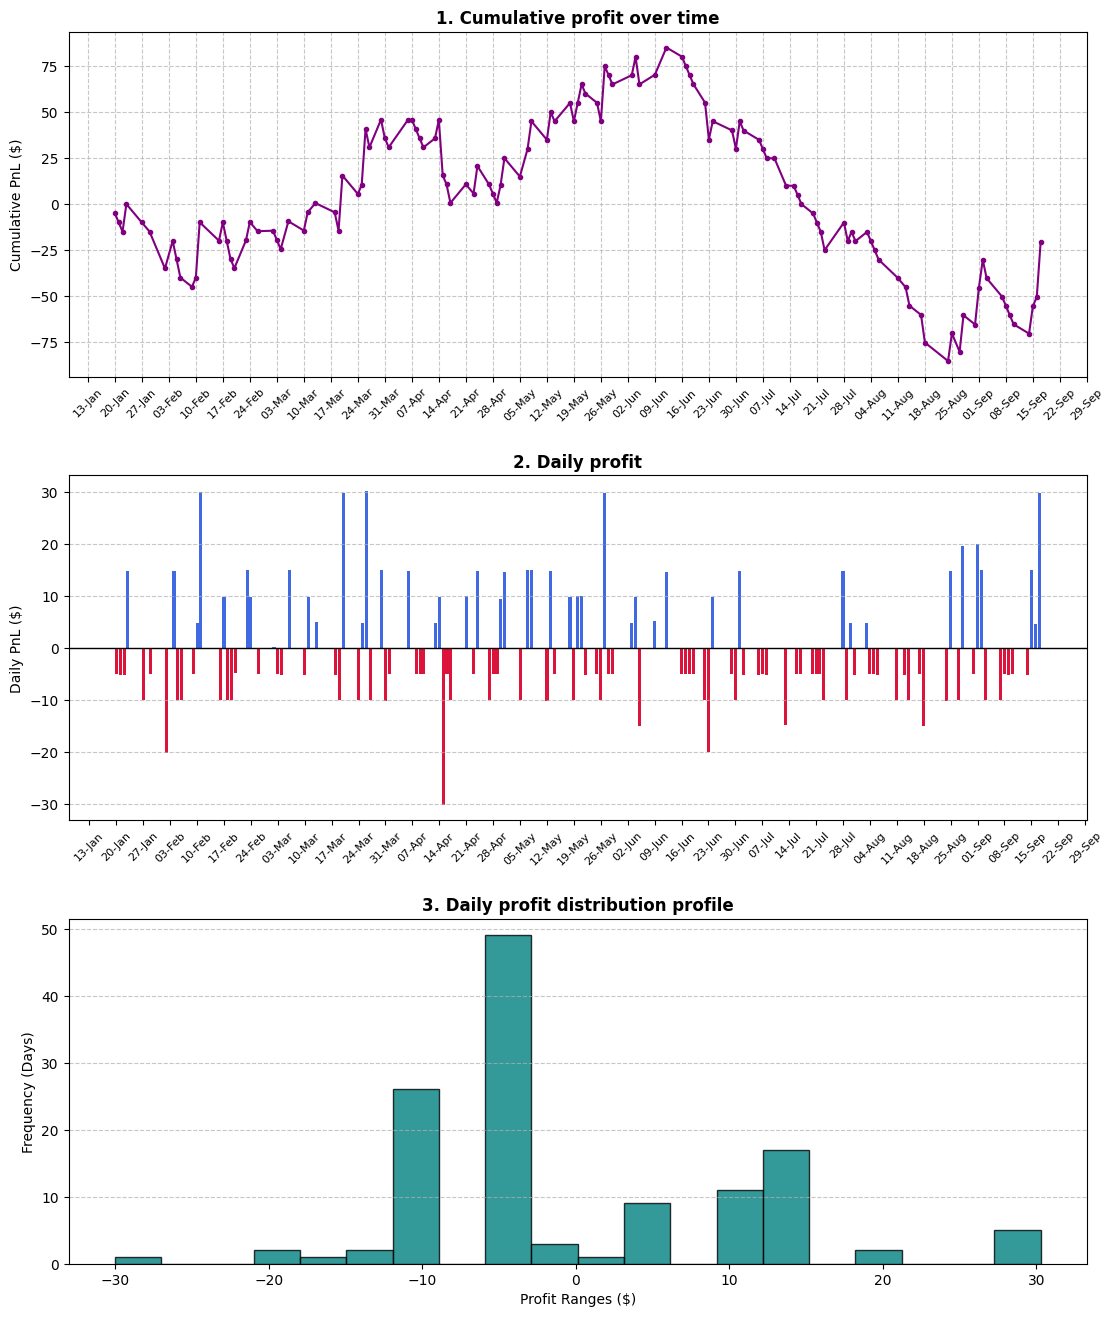

In [4]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from dataclasses import dataclass
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


SYMBOL = "US500.cash"
TIMEFRAME = mt5.TIMEFRAME_M15
RISK_PERCENT = 0.0005
ACCOUNT_SIZE = 10000
BUFFER = 0
RR = 3
FRACTAL_DISTANCE = 20
MAX_OPEN_TRADES_PER_TYPE = 50
MAX_OPEN_COUNTER_TRADES_PER_TYPE = 50

@dataclass
class Trade:
    entry_time: pd.Timestamp
    side: str
    trade_type: str
    entry: float
    sl: float
    tp: float
    volume: float
    exit_time: pd.Timestamp = None
    exit_price: float = None
    pnl: float = 0.0
    min_pnl_seen: float = 0.0

def detect_fractals(df, d):
    df['fractal_high'] = False
    df['fractal_low'] = False
    for i in range(d, len(df) - d):
        if df['low'].iloc[i] == min(df['low'].iloc[i-d:i+d+1]):
            df.at[df.index[i], 'fractal_low'] = True
        if df['high'].iloc[i] == max(df['high'].iloc[i-d:i+d+1]):
            df.at[df.index[i], 'fractal_high'] = True
    return df

def calculate_lot_size(symbol, entry, sl):
    info = mt5.symbol_info(symbol)
    if not info: return 0.1
    tick_value = info.trade_tick_value
    tick_size = info.trade_tick_size
    risk_points = abs(entry - sl)
    if risk_points == 0: return 0.1
    
    lot_risk_value = (risk_points / tick_size) * tick_value
    if lot_risk_value == 0: return 0.1
    
    lot = (ACCOUNT_SIZE * RISK_PERCENT) / lot_risk_value
    lot = max(lot, info.volume_min)
    lot = min(lot, info.volume_max)
    return round(lot, 2)

def calculate_performance_metrics(df_res, initial_balance=ACCOUNT_SIZE):
    total_pnl = df_res['pnl'].sum()
    total_return = (total_pnl / initial_balance) * 100
    
    # Win rate
    winning_trades = df_res[df_res['pnl'] > 0]
    losing_trades = df_res[df_res['pnl'] < 0]
    total_trades = len(df_res)
    win_rate = (len(winning_trades) / total_trades * 100) if total_trades > 0 else 0.0
    
    # Profit factor
    gross_profit = winning_trades['pnl'].sum()
    gross_loss = abs(losing_trades['pnl'].sum())
    profit_factor = (gross_profit / gross_loss) if gross_loss > 0 else np.inf
    
    # Max drawdown 
    df_res['cum_pnl'] = df_res['pnl'].cumsum()
    df_res['equity'] = initial_balance + df_res['cum_pnl']
    df_res['peak'] = df_res['equity'].cummax()
    df_res['drawdown'] = (df_res['equity'] - df_res['peak']) / df_res['peak']
    max_drawdown = df_res['drawdown'].min() * 100 if not df_res.empty else 0.0
    
    # Sharpe ratio (Annualized assuming 252 trading days (not taking into account weekends))
    daily_pnl = df_res.groupby(df_res['exit_time'].dt.date)['pnl'].sum()
    daily_returns = daily_pnl / initial_balance
    
    if len(daily_returns) > 1 and daily_returns.std() != 0:
        sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)
    else:
        sharpe_ratio = 0.0
        
    return {
        'total_return': total_return,
        'win_rate': win_rate,
        'profit_factor': profit_factor,
        'max_drawdown': max_drawdown,
        'sharpe_ratio': sharpe_ratio,
        'total_pnl': total_pnl
    }


def backtest(start, stop):
    print(f"\n Starting SWEEP backtest for {SYMBOL}")
    pre_start = start - timedelta(days=3)
    
    rates = mt5.copy_rates_range(SYMBOL, TIMEFRAME, pre_start, stop)

    if rates is None:
        print("Error fetching data from MT5.")
        return []

    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df = detect_fractals(df, FRACTAL_DISTANCE)

    active_trades = []
    closed_trades = []

    last_saved_high = 0
    last_saved_low = 0
    
    downtrend = False
    uptrend = False
    
    bullish_zones = []  
    bearish_zones = []
    
    # Indices to prevent duplicate triggers
    last_broken_low_idx = None
    last_broken_high_idx = None

    for i in range(100, len(df)):
        row = df.iloc[i]

        if row.time < start: continue

        #Exit management
        for trade in active_trades[:]:
            execute_close = False
            exit_price = 0.0

            if trade.side == 'buy':
                if row.low <= trade.sl:
                    exit_price = trade.sl
                    execute_close = True
                elif row.high >= trade.tp:
                    exit_price = trade.tp
                    execute_close = True
            else:
                if row.high >= trade.sl:
                    exit_price = trade.sl
                    execute_close = True
                elif row.low <= trade.tp:
                    exit_price = trade.tp
                    execute_close = True

            if execute_close:
                trade.exit_price = exit_price
                trade.exit_time = row.time
                move = (trade.exit_price - trade.entry) if trade.side == 'buy' else (trade.entry - trade.exit_price)
                info = mt5.symbol_info(SYMBOL)
                trade.pnl = (move / info.trade_tick_size) * info.trade_tick_value * trade.volume
                
                result = "TP" if trade.pnl > 0 else "SL"
                # COMMENTED_PRINT: print(f"[{row.time}] CLOSE {trade.side.upper()} ({result}) | Price: {exit_price:.2f} | PnL: ${trade.pnl:.2f}")
                
                closed_trades.append(trade)
                active_trades.remove(trade)

        # Structure breaks (CHOCH/BOS)
        # Account for lookahead bias in fractal detection by adding a delay
        lows = df[(df.fractal_low) & (df.index < i)]
        highs = df[(df.fractal_high) & (df.index < i)]
        
        # Check if empty to prevent errrors early in the backtest
        last_high = highs.iloc[-1].high if not highs.empty else None
        last_low = lows.iloc[-1].low if not lows.empty else None

        idx_low = lows.index[-1] if not lows.empty else None
        idx_high = highs.index[-1] if not highs.empty else None

        # Expired fractals: if the fractal index is the same as the one already broken, hide it (LTF only)
        if idx_low == last_broken_low_idx:
            last_low = None
            last_high = None
        if idx_high == last_broken_high_idx:
            last_high = None
            last_low = None

        
        # Structure breaks:
        if last_high is not None and row.close > last_high and last_high != last_saved_high:
            # COMMENTED_PRINT: print(f"[{row.time}] HTF (15m): Price took out a HIGH: ", last_high)
            downtrend = False
            uptrend = True
            last_saved_high = last_high  # Save to avoid duplicate triggers
            last_broken_high_idx = idx_high
            
        elif last_low is not None and row.close < last_low and last_low != last_saved_low:
            # COMMENTED_PRINT: print(f"[{row.time}] HTF (15m): Price took out a LOW: ", last_low)
            downtrend = True
            uptrend = False
            last_saved_low = last_low
            last_broken_low_idx = idx_low

        # Liquidity zones 
        # Register each fractal LOW as a Bullish Zone (Liquidity level below)
        if last_low is not None:
            # Check if this exact price is already registered as a zone
            active_zone = next((z for z in bullish_zones if z['low'] == last_low), None)
            if not active_zone:
                # New low -> add 
                bullish_zones.append({
                    'low': last_low, 
                    'mitigated': False  
                })

        # Register each fractal HIGH as a Bearish Zone (Liquidity level above)
        if last_high is not None:
            # Check if this exact price is already registered as a zone
            active_zone = next((z for z in bearish_zones if z['high'] == last_high), None)
            if not active_zone:
                # New high, add 
                bearish_zones.append({
                    'high': last_high, 
                    'mitigated': False  
                })
        
        n_buys_normal = len([t for t in active_trades if t.side == 'buy'])
        n_sells_normal = len([t for t in active_trades if t.side == 'sell'])
        
        # Filter bullish zones
        active_bullish_zones = []
        buy_opened_in_this_bar = False  # Controls triggers (max 1 buy per bar)
        
        for zone in bullish_zones:
            # 1) Has the zone already triggered a trade? -> Mitigated
            if zone.get('mitigated', False):
                active_bullish_zones.append(zone) 
                continue
                
            # 2) If candle body closes below the level -> structure is broken.
            elif min(row.open, row.close) < zone['low']:
                zone['mitigated'] = True 
                active_bullish_zones.append(zone)  
                continue

            else:
                # 3) Did price SWEEP the level? Execute trade. SWEEP= Open & Close above, low sweeps below.
                if row.open > zone['low'] and row.close > zone['low'] and row.low < zone['low']:
                    zone['mitigated'] = True 
                    
                    # 4) Check available slot and ensure no trade was opened in this bar yet
                    if not buy_opened_in_this_bar and n_buys_normal < MAX_OPEN_TRADES_PER_TYPE:
                        # COMMENTED_PRINT: print(f"[{row.time}] Bullish SWEEP. Swept low {zone['low']:.2f}")
                        entry = row.close  # Entry at the close of the manipulation bar
                        sl = row.low - BUFFER  # SL at the low of the same bar
                        if entry > sl:  # Safety check (ensure downward exists)
                            lot = calculate_lot_size(SYMBOL, entry, sl)
                            tp = entry + RR * (entry - sl)
                            active_trades.append(Trade(row.time, 'buy', 'bullish_sweep', entry, sl, tp, lot))
                            # COMMENTED_PRINT: print(f"[{row.time}] Opening BUY | In: {entry:.2f} | SL: {sl:.2f} | TP: {tp:.2f}")
                            buy_opened_in_this_bar = True
                    
                active_bullish_zones.append(zone)  # Zone mantained
                
        bullish_zones = active_bullish_zones 
        
        # Filter bearish zones
        active_bearish_zones = []
        sell_opened_in_this_bar = False  # Controls triggers (max 1 sell per bar)
        
        for zone in bearish_zones:
            # 1) Has the zone already triggered a trade? -> Mitigated
            if zone.get('mitigated', False):
                active_bearish_zones.append(zone)  
                continue
                
            # 2) If candle body closes above the level -> structure is broken.
            elif max(row.open, row.close) > zone['high']:
                zone['mitigated'] = True 
                active_bearish_zones.append(zone)  
                continue
            else:
                 # 3) Did price SWEEP the level? Execute trade. SWEEP= Open & Close below, hhigh sweeps above.
                if row.open < zone['high'] and row.close < zone['high'] and row.high > zone['high']:
                    zone['mitigated'] = True 
                    
                    # 4) Check available slot and ensure no trade was opened in this bar yet
                    if not sell_opened_in_this_bar and n_sells_normal < MAX_OPEN_TRADES_PER_TYPE:
                        # COMMENTED_PRINT: print(f"[{row.time}] Bearish SWEEP. Swept high {zone['high']:.2f}")
                        entry = row.close  # Entry at the close of the manipulation bar
                        sl = row.high + BUFFER  # SL at the high of the same bar    
                        if sl > entry:  # Safety check (ensure upward exists)
                            lot = calculate_lot_size(SYMBOL, entry, sl)
                            tp = entry - RR * (sl - entry)
                            active_trades.append(Trade(row.time, 'sell', 'bearish_sweep', entry, sl, tp, lot))
                            # COMMENTED_PRINT: print(f"[{row.time}] Opening SELL | In: {entry:.2f} | SL: {sl:.2f} | TP: {tp:.2f}")
                            sell_opened_in_this_bar = True
 
                active_bearish_zones.append(zone)  # Zone mantainned
                
        bearish_zones = active_bearish_zones

    # Closure of remaining open trades at the end of backtest
    for t in active_trades:
        t.exit_price = df.iloc[-1].close
        t.exit_time = df.iloc[-1].time
        move = (t.exit_price - t.entry) if t.side == 'buy' else (t.entry - t.exit_price)
        info = mt5.symbol_info(SYMBOL)
        t.pnl = (move / info.trade_tick_size) * info.trade_tick_value * t.volume
        closed_trades.append(t)

    return closed_trades


if __name__ == "__main__":
    if not mt5.initialize():
        print("MT5 initialization failed")
    else:
        trades = backtest(datetime(2026, 1, 16, 0, 0), datetime(2026, 9, 17, 23, 59)) 
        
        if trades:
            df_res = pd.DataFrame([t.__dict__ for t in trades])
            df_res = df_res.sort_values('entry_time').reset_index(drop=True)
            # COMMENTED_PRINT: print("\n--- TRADES SUMMARY ---")
            # COMMENTED_PRINT: print(df_res[['entry_time','exit_time','side', 'volume', 'entry', 'sl', 'tp', 'exit_price', 'pnl']])
            # COMMENTED_PRINT: print(f"\n Total PnL: ${df_res.pnl.sum():.2f}")

            metrics = calculate_performance_metrics(df_res, ACCOUNT_SIZE)
            print("         PERFORMANCE METRICS SUMMARY:        ")
            print(f"* Total Return:   {metrics['total_return']:.2f}% (${metrics['total_pnl']:.2f})")
            print(f"* Win Rate:       {metrics['win_rate']:.1f}%")
            print(f"* Profit Factor:  {metrics['profit_factor']:.2f}")
            print(f"* Max Drawdown:   {metrics['max_drawdown']:.2f}%")
            print(f"* Sharpe Ratio:   {metrics['sharpe_ratio']:.2f}")
            
            # Plots
            df_res['exit_date'] = df_res['exit_time'].dt.date
            
            # Group daily PnL
            daily_pnl = df_res.groupby('exit_date')['pnl'].sum().reset_index()
            daily_pnl['cum_pnl'] = daily_pnl['pnl'].cumsum()

            daily_pnl['exit_date'] = pd.to_datetime(daily_pnl['exit_date']) # exit_date is a pandas datetime object for matplotlib 

            fig, axs = plt.subplots(3, 1, figsize=(12, 14))
            fig.tight_layout(pad=5.0)

            # Plot 1: Cumulative profit 
            axs[0].plot(daily_pnl['exit_date'], daily_pnl['cum_pnl'], marker='o', linestyle='-', color='purple', markersize=3)
            axs[0].set_title('1. Cumulative profit over time', fontsize=12, fontweight='bold')
            axs[0].set_ylabel('Cumulative PnL ($)')
            axs[0].grid(True, linestyle='--', alpha=0.7)

            # Plot 2: Daily profit
            colors = ['royalblue' if pnl >= 0 else 'crimson' for pnl in daily_pnl['pnl']]
            axs[1].bar(daily_pnl['exit_date'], daily_pnl['pnl'], color=colors, width=0.8) 
            axs[1].set_title('2. Daily profit', fontsize=12, fontweight='bold')
            axs[1].set_ylabel('Daily PnL ($)')
            axs[1].axhline(0, color='black', linewidth=1)
            axs[1].grid(axis='y', linestyle='--', alpha=0.7)

            # X-axis date configuration for plots 1 and 2:Display ticks every N days (change interval=3 to 5, 7, etc.)
            date_locator = mdates.DayLocator(interval=7) 
            
            # Format display: '%Y-%m-%d' (e.g., '2026-06-16') or '%d-%b' (e.g., '16-Jun')
            date_formatter = mdates.DateFormatter('%d-%b') 

            for ax in [axs[0], axs[1]]:
                ax.xaxis.set_major_locator(date_locator)
                ax.xaxis.set_major_formatter(date_formatter)
                ax.tick_params(axis='x', rotation=45, labelsize=8)

            # Plot 3: Daily profit distribution profile 
            axs[2].hist(daily_pnl['pnl'], bins=20, color='teal', edgecolor='black', alpha=0.8)
            axs[2].set_title('3. Daily profit distribution profile', fontsize=12, fontweight='bold')
            axs[2].set_xlabel('Profit Ranges ($)')
            axs[2].set_ylabel('Frequency (Days)')
            axs[2].grid(axis='y', linestyle='--', alpha=0.7)

            plt.show()

        else:
            print("\n No trades were found for the specified period.")
            
        mt5.shutdown()

## 3. Performance and risk analysis

### Summary metrics (15min)
* **Total Return:** -0.36% ($-35.66)
* **Win Rate:** 24.2%
* **Profit Factor:** 0.96
* **Max Drawdown:** -1.69%
* **Sharpe Ratio:** -0.39

---

### Diagnosis: Why did it underperform?

1. **Timeframe selection and noise:** 
   In lower timeframes, candle wicks often represent market noise rather than true institutional liquidity purges. This causes false positives, driving the Win Rate down to 24.2%.

2. **Low drawdown vs. poor expectancy:** 
   Despite the negative return, the Max Drawdown remained exceptionally low (-1.69%). This confirms that the risk management logic (stop-losses) worked correctly, preserving capital even when market direction was incorrect.

3. **Profit factor near 1 (0.96):** 
   A Profit Factor close to 1.0 indicates that while win probability was low, wins were larger than losses. Minor structural changes can push this metric above 1.0.

---

### Parameter optimization Hypotheses

To turn this strategy into a viable generator, the following adjustments can be explored:

* **Higher timeframe filter (HTF Bias):** Executing sweeps exclusively in the direction of the H4/D1 trend to eliminate counter-trend false breakouts.
* **Volume:** Requiring an expansion in volume during the sweep candle to confirm aggressive institutional absorption.
* **Dynamic lookback window:** Replacing static swing windows ($N$-periods) with ATR-based dynamic thresholds to account for changing market volatility regimes.

# Strategy 2: Algorithmic SMC
## 1. Strategy overview
Smart Money Concepts (SMC) attempt to model institutional order flow by identifying key supply/demand imbalances and high-probability order execution zones. 

Rather than relying on technical indicators, this module systematically identifies and backtests execution across four core SMC building blocks: **Decisional Order Blocks (OB)**, **Extreme Order Blocks (OB)**, **Fair Value Gaps (FVG)**, and **Fibonacci Golden Zones ($0.618 - 0.786$)**.

## 2. Theoretical rules 

* **Order Blocks (OB):** The last opposing candle before a strong directional displacement that creates a Break of Structure (BOS).
  * **Extreme OB:** The origin of the entire impulse move (highest/lowest structural point).
  * **Decisional OB:** The last consolidation zone before breaching a minor swing level prior to the main BOS.
* **Fair Value Gaps (FVG):** Three-candle price inefficiencies where the wick of Candle 1 does not overlap with the wick of Candle 3, leaving an unmitigated price imbalance.
* **Golden Zones:** Premium/Discount retracement levels measuring the $61.8\% - 78.6\%$ Fibonacci range of the active swing leg.
* **Execution Baseline:** Systematically places limit orders upon price retesting these unmitigated zones, testing aggregate edge across all identified structures.



 Running SMC Backtest for US500.cash
                 PERFORMANCE METRICS SUMMARY BY STRATEGY:                 
STRATEGY: [OB_EXTREM] (Trades: 457)
  * Total Return:   3.38% ($338.32)
  * Win Rate:       28.7%
  * Profit Factor:  1.21
  * Max Drawdown:   -0.88%
  * Sharpe Ratio:   2.30
--------------------------------------------------------------------------------
STRATEGY: [OB_DECISIONAL] (Trades: 2636)
  * Total Return:   20.39% ($2039.00)
  * Win Rate:       28.9%
  * Profit Factor:  1.22
  * Max Drawdown:   -3.50%
  * Sharpe Ratio:   3.61
--------------------------------------------------------------------------------
STRATEGY: [FVG] (Trades: 513)
  * Total Return:   5.15% ($514.84)
  * Win Rate:       30.0%
  * Profit Factor:  1.29
  * Max Drawdown:   -1.14%
  * Sharpe Ratio:   3.53
--------------------------------------------------------------------------------
STRATEGY: [GOLDEN_ZONE_075] (Trades: 440)
  * Total Return:   6.05% ($604.69)
  * Win Rate:       31.8%
  * Profit Fac

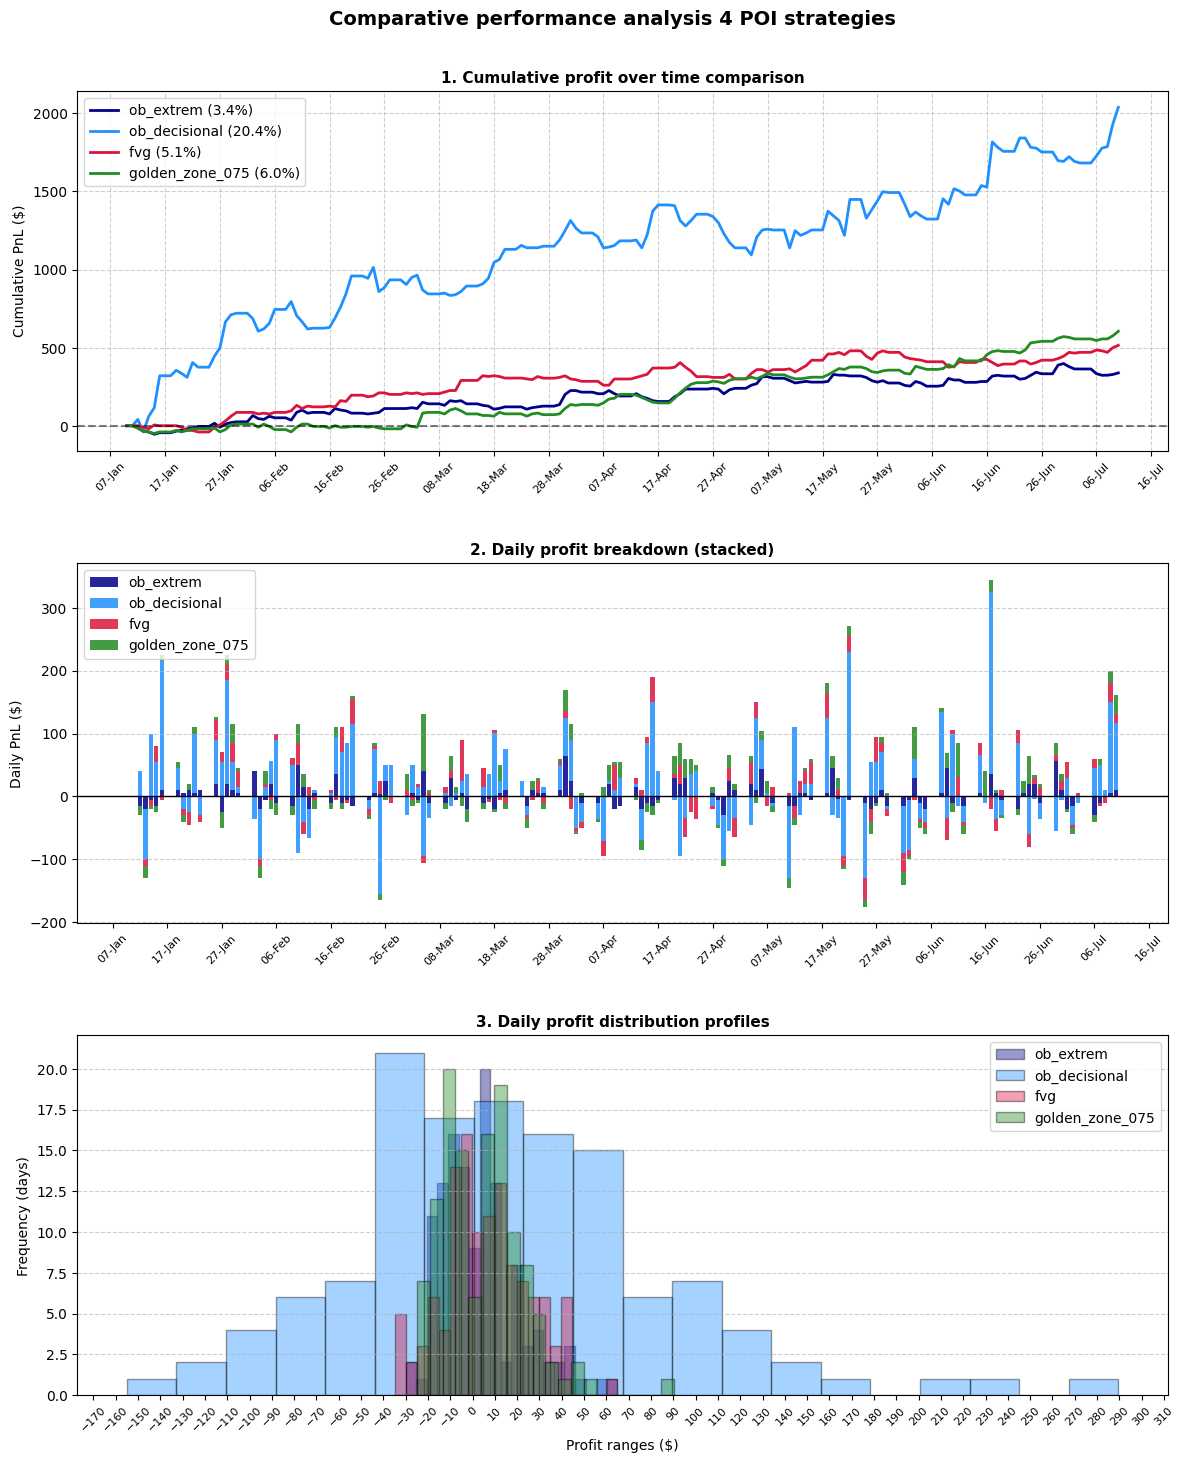

In [5]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from dataclasses import dataclass
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

SYMBOL = "US500.cash"
TIMEFRAME = mt5.TIMEFRAME_M15
RISK_PERCENT = 0.0005
ACCOUNT_SIZE = 10000
BUFFER = 0.1
RR = 3

FRACTAL_DISTANCE = 5
MAX_OPEN_TRADES_PER_TYPE = 10

@dataclass
class Trade:
    entry_time: pd.Timestamp
    side: str
    trade_type: str
    category: str
    entry: float
    sl: float
    tp: float
    volume: float
    exit_time: pd.Timestamp = None
    exit_price: float = None
    pnl: float = 0.0

def detect_fractals(df, distance):
    df['fractal_high'] = False
    df['fractal_low'] = False
    for i in range(distance, len(df) - distance):
        if df['low'].iloc[i] == min(df['low'].iloc[i-distance:i+distance+1]):
            df.at[df.index[i], 'fractal_low'] = True
        if df['high'].iloc[i] == max(df['high'].iloc[i-distance:i+distance+1]):
            df.at[df.index[i], 'fractal_high'] = True
    return df

def detect_fvg(df):
    df['fvg_bullish'] = df['low'].shift(-2) > df['high']
    df['fvg_bearish'] = df['high'].shift(-2) < df['low']

    df['fvg_high'] = np.where(df['fvg_bullish'], df['low'].shift(-2), np.nan)
    df['fvg_low'] = np.where(df['fvg_bullish'], df['high'], np.nan)

    df['fvg_high_bear'] = np.where(df['fvg_bearish'], df['high'], np.nan)
    df['fvg_low_bear'] = np.where(df['fvg_bearish'], df['low'].shift(-2), np.nan)

    return df

def calculate_lot_size(symbol, entry, sl):
    info = mt5.symbol_info(symbol)
    if not info: return 0.1
    tick_value = info.trade_tick_value
    tick_size = info.trade_tick_size
    risk_points = abs(entry - sl)
    if risk_points == 0: return 0.1
    
    risk_value_per_lot = (risk_points / tick_size) * tick_value
    if risk_value_per_lot == 0: return 0.1
    
    lot = (ACCOUNT_SIZE * RISK_PERCENT) / risk_value_per_lot
    lot = max(lot, info.volume_min)
    lot = min(lot, info.volume_max)
    return round(lot, 2)

def backtest(start, stop):
    print(f"\n Running SMC Backtest for {SYMBOL}")
    pre_start = start - timedelta(days=3)
    
    rates = mt5.copy_rates_range(SYMBOL, TIMEFRAME, pre_start, stop)
    if rates is None: return []

    df = pd.DataFrame(rates)
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df = detect_fractals(df, FRACTAL_DISTANCE)
    df = detect_fvg(df)
    df['is_valid_high'] = df['fractal_high']
    df['is_valid_low'] = df['fractal_low']
    
    active_trades = []
    closed_trades = []

    last_saved_high = 0
    last_saved_low = 0
    
    bullish_zones = []
    bearish_zones = []

    for i in range(50, len(df)):
        row = df.iloc[i]
        if row.time < start: continue

        # Highs:
        highs = df[(df.is_valid_high == True) & (df.index < i - FRACTAL_DISTANCE)]
        while len(highs) >= 2:
            last_high = highs.iloc[-1]
            prev_high = highs.iloc[-2]
            if last_high.high > prev_high.high and last_high.close <= prev_high.high:
                df.at[last_high.name, 'is_valid_high'] = False
                highs = df[(df.is_valid_high == True) & (df.index < i - FRACTAL_DISTANCE)]
            else:
                break
                
        last_high_row = highs.iloc[-1] if not highs.empty else None
        last_high = last_high_row.high if last_high_row is not None else None

        # Lows:
        lows = df[(df.is_valid_low == True) & (df.index < i - FRACTAL_DISTANCE)]
        while len(lows) >= 2:
            last_low = lows.iloc[-1]
            prev_low = lows.iloc[-2]
            if last_low.low < prev_low.low and last_low.close >= prev_low.low:
                df.at[last_low.name, 'is_valid_low'] = False
                lows = df[(df.is_valid_low == True) & (df.index < i - FRACTAL_DISTANCE)]
            else:
                break
                
        last_low_row = lows.iloc[-1] if not lows.empty else None
        last_low = last_low_row.low if last_low_row is not None else None

        n_buys = len([t for t in active_trades if t.side == 'buy'])
        n_sells = len([t for t in active_trades if t.side == 'sell'])

        # Buy zones:
        for zone in bullish_zones:  
            if zone['mitigated']: continue
            if row.close <= zone['low']:  
                zone['mitigated'] = True
                continue

            for p_idx in range(len(zone['pois']) - 1, -1, -1):
                poi = zone['pois'][p_idx]
                if poi['mitigated']: continue

                if not poi['activated']:
                    if row.close > poi['high']: poi['activated'] = True
                    continue 
                
                if poi['activated'] and row.low <= poi['high']:
                    poi['mitigated'] = True
                    if n_buys < MAX_OPEN_TRADES_PER_TYPE:
                        entry = poi['high']
                        sl = (zone['low'] - BUFFER) if poi['category'] in ['ob_extrem', 'golden_zone_075'] else (poi['low'] - BUFFER)
                        tp = entry + RR * (entry - sl)
                        lot = calculate_lot_size(SYMBOL, entry, sl)
                        active_trades.append(Trade(row.time, 'buy', 'smc', poi['category'], entry, sl, tp, lot))

        # Sell zones:
        for zone in bearish_zones:  
            if zone['mitigated']: continue
            if row.close >= zone['high']:  
                zone['mitigated'] = True
                continue

            for p_idx in range(len(zone['pois']) - 1, -1, -1):
                poi = zone['pois'][p_idx]
                if poi['mitigated']: continue

                if not poi['activated']:
                    if row.close < poi['low']: poi['activated'] = True
                    continue 
                
                if poi['activated'] and row.high >= poi['low']:
                    poi['mitigated'] = True
                    if n_sells < MAX_OPEN_TRADES_PER_TYPE:
                        entry = poi['low']
                        sl = (zone['high'] + BUFFER) if poi['category'] in ['ob_extrem', 'golden_zone_075'] else (poi['high'] + BUFFER)
                        tp = entry - RR * (sl - entry)
                        lot = calculate_lot_size(SYMBOL, entry, sl)
                        active_trades.append(Trade(row.time, 'sell', 'smc', poi['category'], entry, sl, tp, lot))

        # Confirmation buy:
        if last_high is not None and row.close > last_high and last_high != last_saved_high:
            last_saved_high = last_high
            pullback_leg = df[(df['time'] >= last_high_row.time) & (df['time'] <= row.time)]
            if not pullback_leg.empty:
                idx_min = pullback_leg['low'].idxmin()
                origin_candle = df.loc[idx_min]
                actual_low = origin_candle.low
                independent_pois = []

                gz_75 = row.high - (abs(row.high - actual_low) * 0.75)
                independent_pois.append({
                    'index': -1, 'high': gz_75 + (BUFFER*5), 'low': gz_75 - (BUFFER*5),
                    'type': 'zone', 'category': 'golden_zone_075',
                    'mitigated': False, 'activated': False, 'size': BUFFER*10
                })

                fvg_leg = pullback_leg[pullback_leg['fvg_bullish']]
                for idx, fvg_row in fvg_leg.iterrows():
                    if pd.notna(fvg_row['fvg_high']):
                        independent_pois.append({
                            'index': idx, 'high': fvg_row['fvg_high'], 'low': fvg_row['fvg_low'],
                            'type': 'fvg', 'category': 'fvg',
                            'mitigated': False, 'activated': False,
                            'size': fvg_row['fvg_high'] - fvg_row['fvg_low']
                        })
                
                candidate_obs = []
                for idx, candle in pullback_leg.iterrows():
                    if candle['close'] < candle['open']:  
                        candidate_obs.append({
                            'index': idx, 'high': candle['high'], 'low': candle['low'],
                            'type': 'ob', 'mitigated': False, 'activated': False,
                            'size': abs(candle['high'] - candle['low'])
                        })
                
                candidate_obs = sorted(candidate_obs, key=lambda x: x['low'])
                for k, ob in enumerate(candidate_obs):
                    ob['category'] = 'ob_extrem' if k == 0 else 'ob_decisional'
                    independent_pois.append(ob)

                independent_pois = sorted(independent_pois, key=lambda x: x['high'], reverse=True)
                bullish_zones.append({
                    'low': actual_low, 'high': row.high,
                    'gz': row.high - (abs(actual_low - row.high) * 0.618),
                    'pois': independent_pois, 'armed': False, 'mitigated': False, 'update_time': row.time
                })

        # Confirmation sell:
        if last_low is not None and row.close < last_low and last_low != last_saved_low:
            last_saved_low = last_low
            pullback_leg = df[(df['time'] >= last_high_row.time) & (df['time'] <= row.time)]
            if not pullback_leg.empty:
                idx_max = pullback_leg['high'].idxmax()
                origin_candle = df.loc[idx_max]
                actual_high = origin_candle.high
                independent_pois = []

                gz_75 = row.low + (abs(actual_high - row.low) * 0.75)
                independent_pois.append({
                    'index': -1, 'high': gz_75 + (BUFFER*5), 'low': gz_75 - (BUFFER*5),
                    'type': 'zone', 'category': 'golden_zone_075',
                    'mitigated': False, 'activated': False, 'size': BUFFER*10
                })

                fvg_leg = pullback_leg[pullback_leg['fvg_bearish']]
                for idx, fvg_row in fvg_leg.iterrows():
                    if pd.notna(fvg_row['fvg_high']):
                        independent_pois.append({
                            'index': idx, 'high': fvg_row['fvg_high'], 'low': fvg_row['fvg_low'],
                            'type': 'fvg', 'category': 'fvg',
                            'mitigated': False, 'activated': False,
                            'size': fvg_row['fvg_high'] - fvg_row['fvg_low']
                        })
                
                candidate_obs = []
                for idx, candle in pullback_leg.iterrows():
                    if candle['close'] > candle['open']:  
                        candidate_obs.append({
                            'index': idx, 'high': candle['high'], 'low': candle['low'],
                            'type': 'ob', 'mitigated': False, 'activated': False,
                            'size': abs(candle['high'] - candle['low'])
                        })
                
                candidate_obs = sorted(candidate_obs, key=lambda x: x['high'], reverse=True)
                for k, ob in enumerate(candidate_obs):
                    ob['category'] = 'ob_extrem' if k == 0 else 'ob_decisional'
                    independent_pois.append(ob)

                independent_pois = sorted(independent_pois, key=lambda x: x['low'])
                bearish_zones.append({
                    'high': actual_high, 'low': row.low,
                    'gz': row.low + (abs(actual_high - row.low) * 0.618),
                    'pois': independent_pois, 'armed': False, 'mitigated': False, 'update_time': row.time
                })

        # Trade exit
        for trade in active_trades[:]:
            execute_close = False
            exit_price = 0.0

            if trade.side == 'buy':
                if row.low <= trade.sl:
                    exit_price = trade.sl; execute_close = True
                elif row.high >= trade.tp:
                    exit_price = trade.tp; execute_close = True
            else:
                if row.high >= trade.sl:
                    exit_price = trade.sl; execute_close = True
                elif row.low <= trade.tp:
                    exit_price = trade.tp; execute_close = True

            if execute_close:
                trade.exit_price = exit_price
                trade.exit_time = row.time
                move = (trade.exit_price - trade.entry) if trade.side == 'buy' else (trade.entry - trade.exit_price)
                info = mt5.symbol_info(SYMBOL)
                trade.pnl = (move / info.trade_tick_size) * info.trade_tick_value * trade.volume
                closed_trades.append(trade)
                active_trades.remove(trade)

    for t in active_trades:
        t.exit_price = df.iloc[-1].close
        t.exit_time = df.iloc[-1].time
        move = (t.exit_price - t.entry) if t.side == 'buy' else (t.entry - t.exit_price)
        info = mt5.symbol_info(SYMBOL)
        t.pnl = (move / info.trade_tick_size) * info.trade_tick_value * t.volume
        closed_trades.append(t)

    return closed_trades

def calculate_performance_metrics(df_strat, start_date, end_date, initial_balance=ACCOUNT_SIZE):
    if df_strat.empty:
        return {
            'total_return': 0.0, 'win_rate': 0.0, 'profit_factor': 0.0,
            'max_drawdown': 0.0, 'sharpe_ratio': 0.0, 'total_pnl': 0.0, 'total_trades': 0
        }
        
    total_pnl = df_strat['pnl'].sum()
    total_return = (total_pnl / initial_balance) * 100
    
    winning_trades = df_strat[df_strat['pnl'] > 0]
    losing_trades = df_strat[df_strat['pnl'] < 0]
    total_trades = len(df_strat)
    win_rate = (len(winning_trades) / total_trades * 100) if total_trades > 0 else 0.0
    
    gross_profit = winning_trades['pnl'].sum()
    gross_loss = abs(losing_trades['pnl'].sum())
    profit_factor = (gross_profit / gross_loss) if gross_loss > 0 else np.inf
    
    df_strat = df_strat.sort_values('exit_time').reset_index(drop=True)
    df_strat['cum_pnl'] = df_strat['pnl'].cumsum()
    df_strat['equity'] = initial_balance + df_strat['cum_pnl']
    df_strat['peak'] = df_strat['equity'].cummax()
    df_strat['drawdown'] = (df_strat['equity'] - df_strat['peak']) / df_strat['peak']
    max_drawdown = df_strat['drawdown'].min() * 100 if not df_strat.empty else 0.0
    
    daily_pnl = df_strat.groupby(df_strat['exit_time'].dt.date)['pnl'].sum()
    daily_returns = daily_pnl / initial_balance
    
    total_days = max((end_date - start_date).days, 1)
    trading_days = len(daily_returns)
    
    if len(daily_returns) > 1 and daily_returns.std() != 0 and total_days > 0:
        sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)  
    else:
        sharpe_ratio = 0.0

    return {
        'total_return': total_return,
        'win_rate': win_rate,
        'profit_factor': profit_factor,
        'max_drawdown': max_drawdown,
        'sharpe_ratio': sharpe_ratio,
        'total_pnl': total_pnl,
        'total_trades': total_trades
    }

if __name__ == "__main__":
    if mt5.initialize():
        start_date = datetime(2026, 1, 10, 0, 0)
        end_date = datetime(2026, 7, 10, 23, 59)
        
        trades = backtest(start_date, end_date)
        if trades:
            df_res = pd.DataFrame([t.__dict__ for t in trades])
            
            strategies = ['ob_extrem', 'ob_decisional', 'fvg', 'golden_zone_075']
            colors = {
                'ob_extrem': 'darkblue',
                'ob_decisional': 'dodgerblue',
                'fvg': 'crimson',
                'golden_zone_075': 'forestgreen'
            }
            
            # Metrics
            print("                 PERFORMANCE METRICS SUMMARY BY STRATEGY:                 ")
            
            metrics_by_strat = {}
            for strat in strategies:
                df_strat = df_res[df_res['category'] == strat].copy()
                m = calculate_performance_metrics(df_strat, start_date, end_date, ACCOUNT_SIZE)
                metrics_by_strat[strat] = m
                
                print(f"STRATEGY: [{strat.upper()}] (Trades: {m['total_trades']})")
                print(f"  * Total Return:   {m['total_return']:.2f}% (${m['total_pnl']:.2f})")
                print(f"  * Win Rate:       {m['win_rate']:.1f}%")
                print(f"  * Profit Factor:  {m['profit_factor']:.2f}")
                print(f"  * Max Drawdown:   {m['max_drawdown']:.2f}%")
                print(f"  * Sharpe Ratio:   {m['sharpe_ratio']:.2f}")
                print("-" * 80)
            
            # Plots:
            fig, axs = plt.subplots(3, 1, figsize=(13, 15))
            fig.tight_layout(pad=6.0)
            fig.suptitle('Comparative performance analysis 4 POI strategies', fontsize=14, fontweight='bold', y=0.995)

            all_dates = pd.date_range(start=start_date.date(), end=end_date.date(), freq='D')
            daily_pnl_df = pd.DataFrame({'date': all_dates}).set_index('date')

            for strat in strategies:
                df_strat = df_res[df_res['category'] == strat].copy()
                if df_strat.empty: continue
                
                df_strat['exit_date'] = pd.to_datetime(df_strat['exit_time'].dt.date)
                strat_daily = df_strat.groupby('exit_date')['pnl'].sum()
                daily_pnl_df[strat] = strat_daily

            daily_pnl_df = daily_pnl_df.fillna(0)

            # Plot 1:
            for strat in strategies:
                cum_pnl = daily_pnl_df[strat].cumsum()
                axs[0].plot(daily_pnl_df.index, cum_pnl, label=f"{strat} ({metrics_by_strat[strat]['total_return']:.1f}%)", color=colors[strat], linewidth=2)
            
            axs[0].set_title('1. Cumulative profit over time comparison', fontsize=11, fontweight='bold')
            axs[0].set_ylabel('Cumulative PnL ($)')
            axs[0].axhline(0, color='black', linestyle='--', alpha=0.5)
            axs[0].grid(True, linestyle='--', alpha=0.6)
            axs[0].legend(loc='upper left')

            # Plot 2:
            bottom_pos = np.zeros(len(daily_pnl_df))
            bottom_neg = np.zeros(len(daily_pnl_df))

            for strat in strategies:
                vals = daily_pnl_df[strat].values
                pos_vals = np.where(vals > 0, vals, 0)
                neg_vals = np.where(vals < 0, vals, 0)
                
                axs[1].bar(daily_pnl_df.index, pos_vals, bottom=bottom_pos, color=colors[strat], alpha=0.85, width=0.8, label=strat)
                axs[1].bar(daily_pnl_df.index, neg_vals, bottom=bottom_neg, color=colors[strat], alpha=0.85, width=0.8)
                
                bottom_pos += pos_vals
                bottom_neg += neg_vals

            axs[1].set_title('2. Daily profit breakdown (stacked)', fontsize=11, fontweight='bold')
            axs[1].set_ylabel('Daily PnL ($)')
            axs[1].axhline(0, color='black', linewidth=1)
            axs[1].grid(axis='y', linestyle='--', alpha=0.6)
            axs[1].legend(loc='upper left')

            date_locator = mdates.DayLocator(interval=10) 
            date_formatter = mdates.DateFormatter('%d-%b') 

            for ax in [axs[0], axs[1]]:
                ax.xaxis.set_major_locator(date_locator)
                ax.xaxis.set_major_formatter(date_formatter)
                ax.tick_params(axis='x', rotation=45, labelsize=8)

            # Plot 3:
            for strat in strategies:
                pnl_vals = daily_pnl_df[daily_pnl_df[strat] != 0][strat]
                if not pnl_vals.empty:
                    axs[2].hist(pnl_vals, bins=20, color=colors[strat], alpha=0.4, label=strat, edgecolor='black')

            axs[2].set_title('3. Daily profit distribution profiles', fontsize=11, fontweight='bold')
            axs[2].set_xlabel('Profit ranges ($)')
            axs[2].set_ylabel('Frequency (days)')
            axs[2].grid(axis='y', linestyle='--', alpha=0.6)
            axs[2].legend(loc='upper right')
            axs[2].xaxis.set_major_locator(ticker.MultipleLocator(10))
            axs[2].tick_params(axis='x', rotation=45, labelsize=8)

            plt.show()

        else:
            print("\n No trades executed in the specified period.")
        mt5.shutdown()

## 3. Performance and risk analysis

| Strategy Component | Trades | Total Return (%) | Win Rate (%) | Profit Factor | Max Drawdown (%) | Sharpe Ratio |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **OB_EXTREM** | 457 | 3.38% | 28.7% | 1.21 | -0.88% | 2.30 |
| **OB_DECISIONAL** | 2,636 | **20.39%** | 28.9% | 1.22 | -3.50% | 3.61 |
| **FVG** | 513 | 5.15% | 30.0% | 1.29 | -1.14% | 3.53 |
| **GOLDEN_ZONE_075** | 440 | 6.05% | **31.8%** | **1.40** | **-0.70%** | **4.20** |


OB_EXTREM
\
The OB_EXTREM strategy generated a 3.38% total return across 457 trades, with a profit factor of 1.21, indicating a modest but positive trading edge. Its 28.7% win rate is relatively low, suggesting that profitability relies heavily on the magnitude of winning trades relative to losses rather than on a high frequency of successful trades. The strategy exhibited a very limited maximum drawdown of -0.88%, while achieving a Sharpe ratio of 2.30, indicating a favorable risk-adjusted return profile. Overall, the strategy demonstrates relatively low risk exposure but a comparatively limited absolute return.

OB_DECISIONAL
\
OB_DECISIONAL produced the highest absolute return, reaching 20.39% over 2,636 trades. Despite a low 28.9% win rate, its profit factor of 1.22 confirms that the aggregate size of profitable trades exceeded that of losing trades. The strategy recorded a maximum drawdown of -3.50%, which is the largest among the four strategies, reflecting a higher level of downside exposure. Nevertheless, its Sharpe ratio of 3.61 indicates strong risk-adjusted performance. The combination of high return, substantial trading activity, and strong Sharpe ratio suggests that OB_DECISIONAL captures a persistent edge, although at the cost of greater drawdown.

FVG
\
The FVG strategy achieved a 5.15% total return over 513 trades and exhibited a profit factor of 1.29, higher than both order-block strategies. Its 30.0% win rate remains relatively low, again indicating that profitability is primarily driven by the payoff asymmetry between winning and losing trades. With a maximum drawdown of only -1.14% and a Sharpe ratio of 3.53, FVG demonstrates a particularly attractive balance between return generation and risk. Compared with OB_EXTREM, it delivers substantially stronger risk-adjusted performance while maintaining similarly low drawdown levels.

GOLDEN_ZONE_075
\
GOLDEN_ZONE_075 displays the strongest risk-adjusted performance among the strategies. It generated a 6.05% total return from 440 trades, while achieving the highest profit factor (1.40) and Sharpe ratio (4.20) in the sample. Its 31.8% win rate is also the highest, although it remains below 50%, meaning that the strategy still depends on favorable reward-to-risk characteristics rather than a majority of winning trades. Most notably, the strategy experienced only a -0.70% maximum drawdown, the lowest of all four approaches. This combination of relatively high return, low drawdown, and strong profitability per unit of risk indicates a highly efficient performance profile within the tested strategies.


#### COMPARISON:
From a risk-adjusted perspective, GOLDEN_ZONE_075 stands out, combining the highest Sharpe ratio (4.20), highest profit factor (1.40), highest win rate (31.8%), and lowest maximum drawdown (-0.70%).

OB_DECISIONAL, however, generated by far the highest absolute return (20.39%) and had substantially more trading activity (2,636 trades). Its higher maximum drawdown suggests that this additional return came with greater risk exposure.

FVG occupies an intermediate position, providing a relatively strong Sharpe ratio (3.53) and profit factor (1.29) while maintaining a low maximum drawdown (-1.14%).

Overall, the results suggest that the strategies exhibit positive expectancy despite relatively low win rates, with profitability apparently driven by favorable asymmetry. The main distinction between them lies in how efficiently they convert this edge into returns relative to drawdown and volatility.

HOWEVER, these metrics should ideally be evaluated together with transaction costs, slippage, out-of-sample performance, and statistical significance. The large difference in trade count means that the strategies are not directly comparable solely on total return.